# Lab - Grupowanie

1. Wczytaj zbiór w `housing.csv`. Usuń wiersze zawierające brakujące wartości. Koduj zmienne kategoryczne metodą `get_dummies()`. Skaluj dane.
    - Użyj [`KMeans()`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) do grupowania zbioru.
    - Stwórz wykres zależności WCSS (atrybut `inertia_`) od `n_clusters`. Na podstawie wykresu wybierz odpowiednią liczbę grup.
    - Wizualizuj dane po grupowaniu. Stwórz na przykład wykres punktowy z `longitude` na osi x i `latitude` na osi y, gdzie kolor reprezentuje indeks grupy (dostępny w `labels_`).
    - Grupuj zbiór przy pomocy [AgglomerativeClustering()](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html). Liczbę grup reguluje parametr `n_clusters` lub `distance_threshold`. Porównaj wizualnie grupowania stworzone przez k-means i grupowanie aglomeracyjne.


In [26]:
import pandas as pd
housing = pd.read_csv('housing.csv')

In [27]:
housing.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [28]:
housing.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [29]:
housing = housing.dropna()

In [30]:
housing.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [31]:
dummies = pd.get_dummies(housing.ocean_proximity)

In [32]:
housing = housing.drop(['ocean_proximity'], axis=1)

In [33]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [34]:
dummies

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,True,False
...,...,...,...,...,...
20635,False,True,False,False,False
20636,False,True,False,False,False
20637,False,True,False,False,False
20638,False,True,False,False,False


In [36]:
housing = pd.concat([housing, dummies], axis=1)

In [37]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,False,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,False,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,False,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,False,True,False,False,False


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering

In [39]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
housing_scaled = scaler.fit_transform(housing)

K=1, WCSS=286062.00
K=2, WCSS=240242.40
K=3, WCSS=201076.11
K=4, WCSS=171940.32
K=5, WCSS=147214.80
K=6, WCSS=126752.01
K=7, WCSS=116177.83
K=8, WCSS=106703.22
K=9, WCSS=98334.91
K=10, WCSS=91680.45
K=11, WCSS=86144.35
K=12, WCSS=81450.55
K=13, WCSS=78054.88
K=14, WCSS=75415.95
K=15, WCSS=72807.04
K=16, WCSS=70957.46
K=17, WCSS=68692.93
K=18, WCSS=66555.06
K=19, WCSS=64148.51


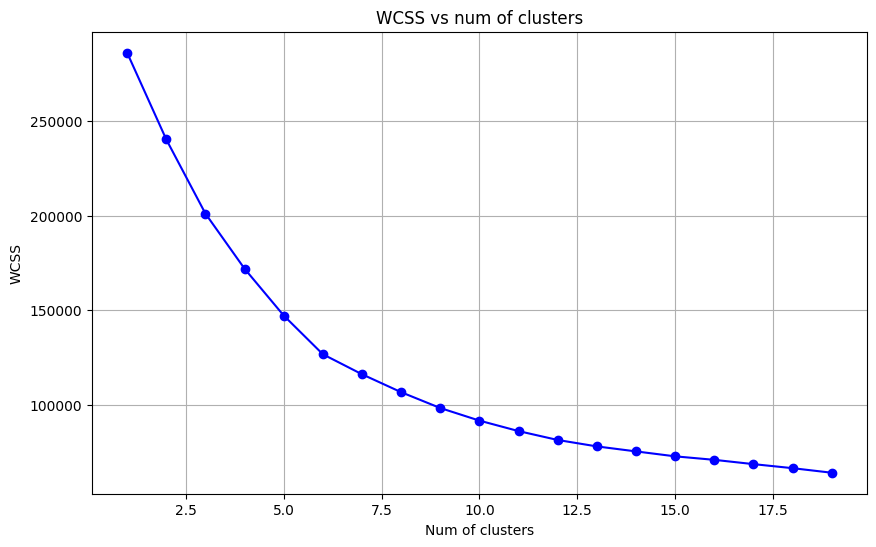

In [41]:
wcss = []
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(housing_scaled)
    wcss.append(kmeans.inertia_)
    print(f"K={k}, WCSS={kmeans.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-')
plt.title('WCSS vs num of clusters')
plt.xlabel('Num of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [58]:
optimal_k = 6

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(housing_scaled)

unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Klaster {cluster}: {count} punktów")

print(f"\nWCSS (inertia): {kmeans.inertia_:.2f}")

Klaster 0: 8410 punktów
Klaster 1: 6012 punktów
Klaster 2: 2198 punktów
Klaster 3: 1262 punktów
Klaster 4: 2546 punktów
Klaster 5: 5 punktów

WCSS (inertia): 126752.01


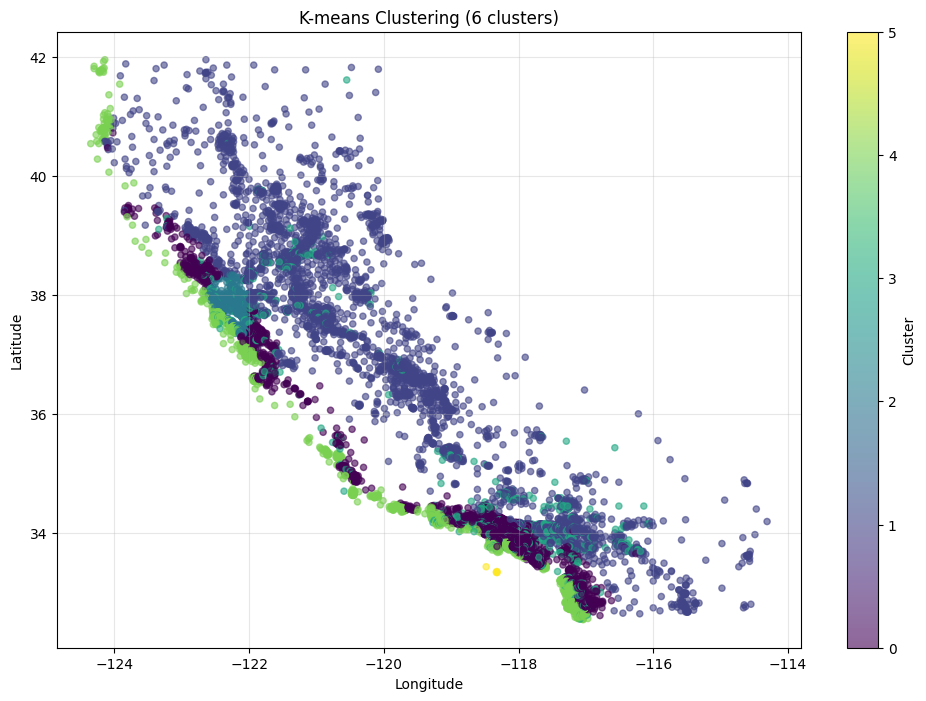

In [62]:
# Wizualizacja K-means clustering
plt.figure(figsize=(12, 8))
scatter = plt.scatter(housing['longitude'], housing['latitude'], 
                     c=kmeans_labels, cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-means Clustering ({optimal_k} clusters)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(housing_scaled)

unique, counts = np.unique(agg_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} points")

Cluster 0: 3375 points
Cluster 1: 6700 points
Cluster 2: 2255 points
Cluster 3: 5563 points
Cluster 4: 2535 points
Cluster 5: 5 points


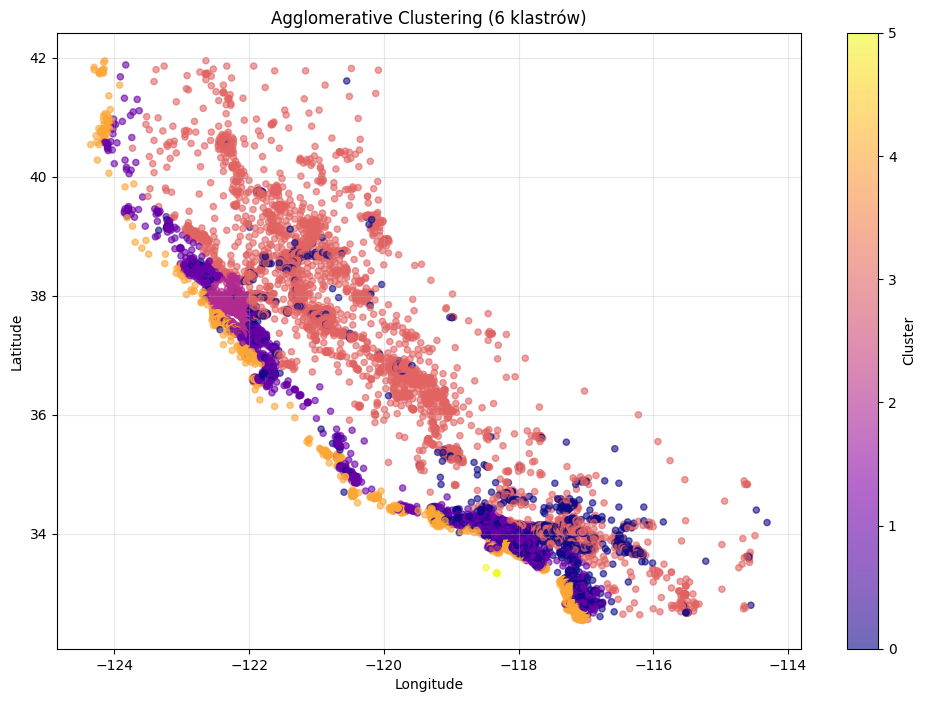

In [61]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(housing['longitude'], housing['latitude'], 
                     c=agg_labels, cmap='plasma', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Agglomerative Clustering ({optimal_k} klastrów)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

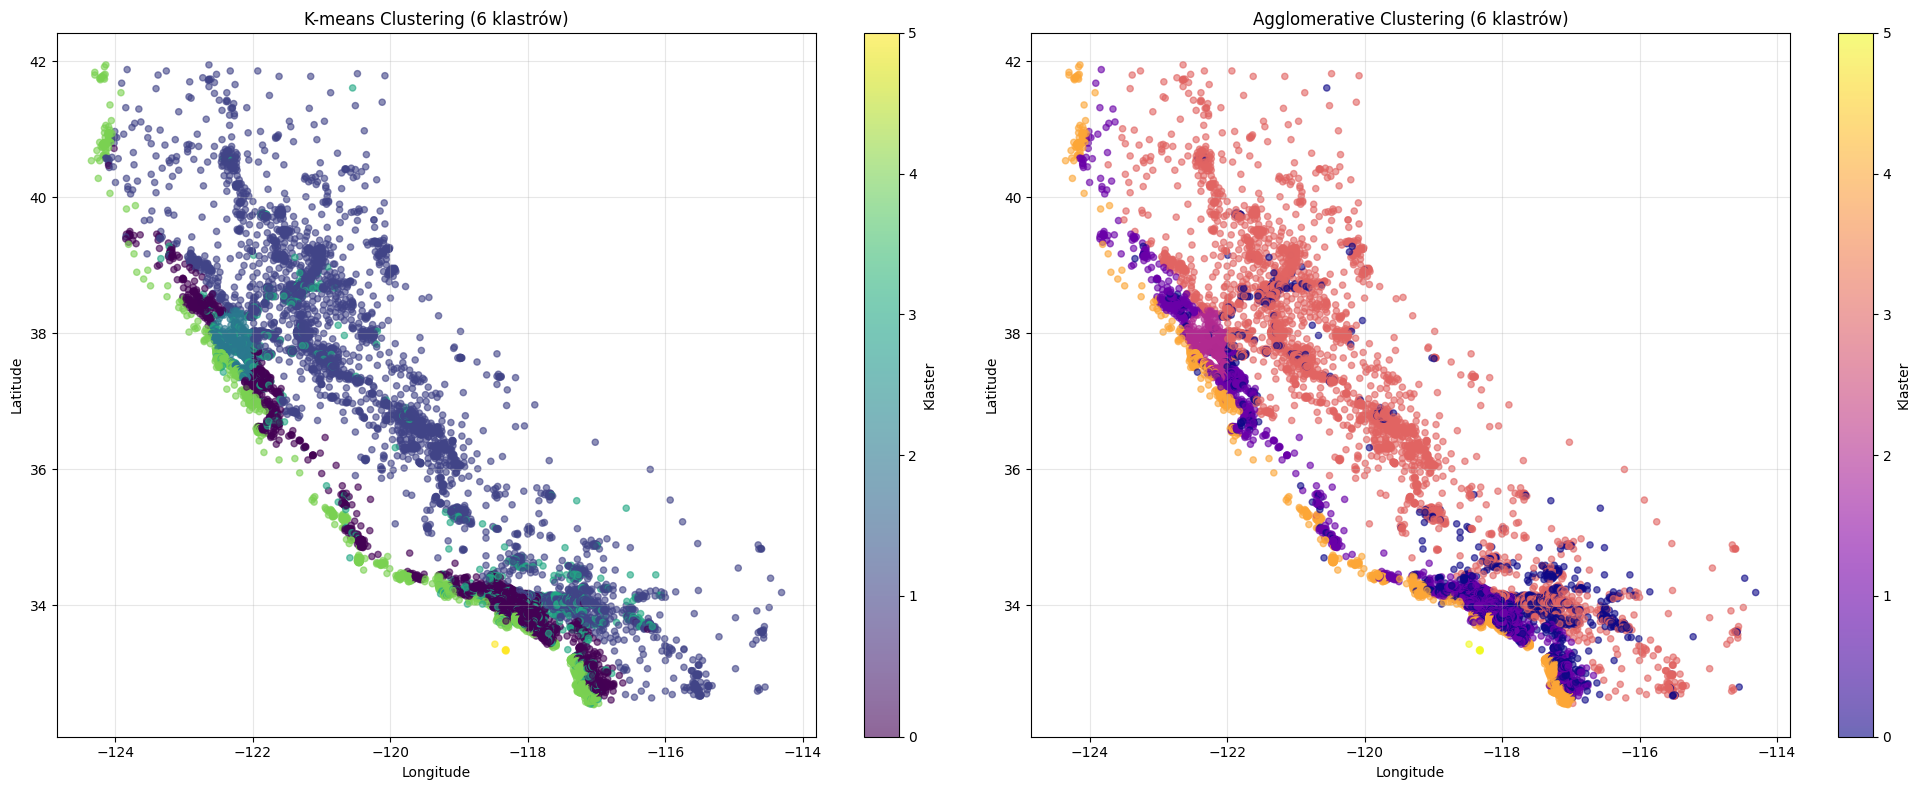

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

scatter1 = ax1.scatter(housing['longitude'], housing['latitude'], 
                      c=kmeans_labels, cmap='viridis', alpha=0.6, s=20)
ax1.set_title(f'K-means Clustering ({optimal_k} klastrów)')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Klaster')

scatter2 = ax2.scatter(housing['longitude'], housing['latitude'], 
                      c=agg_labels, cmap='plasma', alpha=0.6, s=20)
ax2.set_title(f'Agglomerative Clustering ({optimal_k} klastrów)')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Klaster')

plt.tight_layout()
plt.show()